In [8]:
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from sentence_transformers import SentenceTransformer
from pathlib import Path 
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
import numpy as np
from umap import UMAP
from hdbscan import HDBSCAN
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import re
from openai import OpenAI
from bertopic.representation import OpenAI as OpenAIRepresentation
from dotenv import load_dotenv 
import os
load_dotenv()

True

In [9]:
DIRECTORY = Path.cwd().parent / "csv"
macro_groups_df= pd.read_csv(DIRECTORY / "macro_community_groups.csv")
macro_groups_df.head(10)

,Macro_Community,DOIs,PaperTitles,Abstracts
0,0,10.1177/000312240406900204; 10.1177/2329496514540131; 10...,The Structure of a Social Science Collaboration Network:...,Is domain-spanning beneficial? Can it promote innovation...
1,1,10.1162/neco.1989.1.4.541; 10.1109/TPAMI.2013.50; 10.114...,Backpropagation Applied to Handwritten Zip Code Recognit...,The success of machine learning algorithms generally dep...
2,2,10.1145/3038912.3052558; 10.1137/0152031; 10.1145/293967...,Explicit Semantic Ranking for Academic Search via Knowle...,Learning to rank for Information Retrieval (IR) is a tas...
3,3,10.1137/0713009; 10.1007/BF02163027; 10.1007/BF01436084;...,Generalizing the Singular Value Decomposition; Singular ...,NaN
4,4,10.1145/2020408.2020566; 10.14778/1687627.1687709; 10.11...,Compression of weighted graphs; Graph Clustering Based o...,The network structure of a hyperlinked environment can b...
5,5,10.1109/TKDE.2018.2807452; 10.1609/aaai.v32i1.11885; 10....,"A Comprehensive Survey of Graph Embedding: Problems, Tec...",Graph is an important data representation which appears ...
6,6,10.18653/v1/N19-1361; 10.1109/JCDL.2019.00122; 10.18653/...,Structural Scaffolds for Citation Intent Classification ...,Identifying the intent of a citation in scientific paper...
7,7,10.1007/BF01098364; 10.1007/BF02122549; 10.1137/0202001;...,The maximum clique problem; Optima of dual integer linea...,AbstractThis paper presents some recent results on lower...
8,8,10.1002/1097-024X(200009)30:11%3C1203::AID-SPE338%3E3.0....,An open graph visualization system and its applications ...,AbstractA general‐purpose browser for directed graphs is...
9,9,10.1007/s00211-007-0114-x; 10.1007/s00211-007-0061-6; 10...,Fast linear algebra is stable; Fast matrix multiplicatio...,"In Demmel et al. (Numer. Math. 106(2), 199–224, 2007) we..."


In [15]:
def clean_text(text):
    text = text.strip()
    text = re.sub(r'^abstract\s*[:.\-\u2014\u2013]?\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'doi:\S+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\[\d+[\d,;\s\-]*\]', '', text)
    text = re.sub(r'\{[^}]*\}', '', text)
    text = re.sub(r'[\[\](){}]', '', text)
    text = re.sub(r'[\u2010\u2011\u2012\u2013\u2014\u2015]', '-', text)
    text = re.sub(r'[^\x20-\x7E\-]', ' ', text)
    text = re.sub(r'[@#$%^&*_=+|\\<>~`/\"\':;!?,]', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    return text.strip()

def clean_joined_field(field_value):
    items = str(field_value).split('; ')
    cleaned = []
    for item in items:
        c = clean_text(item)
        if c:
            cleaned.append(c)
    return '; '.join(cleaned)


macro_groups_df['PaperTitles'] = macro_groups_df['PaperTitles'].apply(
    lambda x: clean_joined_field(x) if pd.notna(x) else x
)

macro_groups_df['Abstracts'] = macro_groups_df['Abstracts'].apply(
    lambda x: clean_joined_field(x) if pd.notna(x) else x
)

macro_groups_df


,Macro_Community,DOIs,PaperTitles,Abstracts
0,0,10.1177/000312240406900204; 10.1177/2329496514540131; 10...,The Structure of a Social Science Collaboration Network ...,Is domain-spanning beneficial Can it promote innovation ...
1,1,10.1162/neco.1989.1.4.541; 10.1109/TPAMI.2013.50; 10.114...,Backpropagation Applied to Handwritten Zip Code Recognit...,The success of machine learning algorithms generally dep...
2,2,10.1145/3038912.3052558; 10.1137/0152031; 10.1145/293967...,Explicit Semantic Ranking for Academic Search via Knowle...,Learning to rank for Information Retrieval IR is a task ...
3,3,10.1137/0713009; 10.1007/BF02163027; 10.1007/BF01436084;...,Generalizing the Singular Value Decomposition; Singular ...,NaN
4,4,10.1145/2020408.2020566; 10.14778/1687627.1687709; 10.11...,Compression of weighted graphs; Graph Clustering Based o...,The network structure of a hyperlinked environment can b...
5,5,10.1109/TKDE.2018.2807452; 10.1609/aaai.v32i1.11885; 10....,A Comprehensive Survey of Graph Embedding Problems Techn...,Graph is an important data representation which appears ...
6,6,10.18653/v1/N19-1361; 10.1109/JCDL.2019.00122; 10.18653/...,Structural Scaffolds for Citation Intent Classification ...,Identifying the intent of a citation in scientific paper...
7,7,10.1007/BF01098364; 10.1007/BF02122549; 10.1137/0202001;...,The maximum clique problem; Optima of dual integer linea...,This paper presents some recent results on lower bounds ...
8,8,10.1002/1097-024X(200009)30:11%3C1203::AID-SPE338%3E3.0....,An open graph visualization system and its applications ...,A general-purpose browser for directed graphs is describ...
9,9,10.1007/s00211-007-0114-x; 10.1007/s00211-007-0061-6; 10...,Fast linear algebra is stable; Fast matrix multiplicatio...,In Demmel et al. Numer. Math. 1062 199-224 2007 we showe...


In [ ]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
macro_community_topics = {}

representation_model = MaximalMarginalRelevance(diversity=0.3)

academic_stop_words = list(ENGLISH_STOP_WORDS) + [
    'paper', 'propose', 'proposed', 'based', 'using', 'results',
    'show', 'shown', 'present', 'presents', 'presented',
    'study', 'new', 'novel', 'use', 'used', 'also', 'work',
    'two', 'one', 'first', 'abstract', 'approach', 'approaches'
]

def deduplicate_keywords(topic_words, top_n=5):
    keywords = [word for word, _ in topic_words]
    selected_ngrams = [kw for kw in keywords if ' ' in kw]
    covered = set()
    for ngram in selected_ngrams:
        for part in ngram.split():
            covered.add(part)
    result = []
    for kw in keywords:
        if ' ' not in kw and kw in covered:
            continue
        result.append(kw)
        if len(result) >= top_n:
            break
    for kw in keywords:
        if len(result) >= top_n:
            break
        if kw not in result:
            result.append(kw)
    return result[:top_n]

def compute_coherence(topic_model, documents, valid_topics):
    tokenized_docs = [doc.lower().split() for doc in documents]
    dictionary = Dictionary(tokenized_docs)

    topic_words_list = []
    for _, topic_row in valid_topics.iterrows():
        topic_id = topic_row['Topic']
        words = topic_model.get_topic(topic_id)
        # Flatten n-grams to constituent words for coherence calculation
        flattened = []
        for word, _ in words[:10]:
            flattened.extend(word.split())
        # Deduplicate while preserving order
        seen = set()
        unique_words = [w for w in flattened if not (w in seen or seen.add(w))]
        topic_words_list.append(unique_words[:10])

    if not topic_words_list:
        return 0.0

    coherence_model = CoherenceModel(
        topics=topic_words_list,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return coherence_model.get_coherence()

def build_filtered_vocab(documents, stop_words, min_df, ngram_range, max_features):
    pre_vec = CountVectorizer(
        stop_words=stop_words,
        min_df=min_df,
        ngram_range=ngram_range,
        max_features=max_features
    )
    pre_vec.fit(documents)

    return CountVectorizer(
        stop_words=stop_words,
        vocabulary=pre_vec.vocabulary_
    )

for _, row in macro_groups_df.iterrows():
    macro_id = row['Macro_Community']
    documents = []

    if pd.notna(row['PaperTitles']):
        titles = str(row['PaperTitles']).split('; ')
        documents.extend(titles)

    if 'Abstracts' in row and pd.notna(row['Abstracts']):
        abstracts = str(row['Abstracts']).split('; ')
        combined_docs = []
        for i, title in enumerate(titles):
            if i < len(abstracts) and abstracts[i]:
                combined_docs.append(f"{title}. {abstracts[i]}")
            else:
                combined_docs.append(title)
        documents = combined_docs

    print(f"Macro Community: {macro_id} - Documents: {len(documents)}")

    if len(documents) < 3:
        print("Skipping: Not enough documents for topic modeling")
        continue

    # Pre-filter vocabulary at document level, then wrap for BERTopic
    adaptive_min_df = max(2, int(len(documents) * 0.01))
    vectorizer_model = build_filtered_vocab(
        documents,
        stop_words=academic_stop_words,
        min_df=adaptive_min_df,
        ngram_range=(1, 3),
        max_features=1000
    )

    # Explicit UMAP for stable, coherent dimensionality reduction
    umap_model = UMAP(
        n_neighbors=5,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )

    # Explicit HDBSCAN for tighter clusters with less noise
    min_cluster = max(2, len(documents) // 10)
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster,
        min_samples=1,
        metric='euclidean',
        prediction_data=True
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        nr_topics='auto',
        top_n_words=10,
        calculate_probabilities=False,
        verbose=False
    )

    try:
        topics_result, _ = topic_model.fit_transform(documents)
        topic_info = topic_model.get_topic_info()

        valid_topics = topic_info[topic_info['Topic'] != -1]
        num_topics = len(valid_topics)

        print(f"  Topics discovered: {num_topics}")

        if num_topics > 0:
            # Compute coherence score
            coherence = compute_coherence(topic_model, documents, valid_topics)
            print(f"  Coherence (c_v): {coherence:.4f}")

            topic_details = []
            for _, topic_row in valid_topics.iterrows():
                topic_id = topic_row['Topic']
                topic_words = topic_model.get_topic(topic_id)
                keywords = deduplicate_keywords(topic_words, top_n=5)
                score = topic_row['Count'] / len(documents)

                topic_details.append({
                    'topic_id': topic_id,
                    'keywords': keywords,
                    'count': topic_row['Count'],
                    'score': score
                })

                print(f"    Topic {topic_id}: {', '.join(keywords)} [Score: {score:.4f}]")

            macro_community_topics[int(macro_id)] = {
                'num_topics': num_topics,
                'topic_details': topic_details,
                'topic_model': topic_model,
                'num_documents': len(documents),
                'coherence': coherence,
                'documents': documents
            }
        else:
            print("  No distinct topics found")

    except Exception as e:
        print(f"  Error processing Macro Community {macro_id}: {e}")
        continue

Macro Community: 0 - Documents: 639
  Topics discovered: 3
  Coherence (c_v): 0.3644
    Topic 0: research, impact, citation, sociology, academic [Score: 0.6260]
    Topic 1: women, implicit, discrimination, stereotypes, america [Score: 0.1737]
    Topic 2: word, semantic, language, embeddings, cultural [Score: 0.1721]
Macro Community: 1 - Documents: 440
  Topics discovered: 4
  Coherence (c_v): 0.3164
    Topic 0: sparse, selection, recognition, models, dimensionality [Score: 0.3909]
    Topic 1: networks, neural, convolutional, images, features [Score: 0.2568]
    Topic 2: gene, data, networks, pathways, tools [Score: 0.1182]
    Topic 3: speech, connectionist, training, markov, adaptation [Score: 0.1091]
Macro Community: 2 - Documents: 293
  Topics discovered: 4
  Coherence (c_v): 0.3842
    Topic 0: retrieval, images, fashion, multimedia, similarity [Score: 0.4266]
    Topic 1: algorithms, distributed, socialite, frameworks, clusters [Score: 0.2526]
    Topic 2: filtering, recommen

In [ ]:
# 5. LLM-Powered Topic Label & Summary Generation

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

LLM_MODEL = "gpt-4o-mini"  # Change to your preferred model

def generate_topic_label(keywords, representative_docs, model=LLM_MODEL):
    """Call OpenAI to generate a title and summary for a single topic."""
    docs_text = "\n".join(f"- {doc[:300]}" for doc in representative_docs[:10])
    keywords_text = ", ".join(keywords)

    prompt = f"""I have a topic from academic research that is described by the following keywords:
                {keywords_text}

                Representative documents in this topic:
                {docs_text}

                Based on the keywords and documents above, generate:
                1. A short, descriptive academic topic TITLE (3-7 words).
                2. A one-sentence SUMMARY explaining the research theme.

                Format your response exactly as:
                Title: <title>
                Summary: <summary>"""

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are an expert academic research analyst. Generate concise, accurate topic labels."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3,
        max_tokens=150
    )
    return response.choices[0].message.content.strip()

def parse_llm_response(response_text):
    title = ""
    summary = ""
    for line in response_text.split("\n"):
        line = line.strip()
        if line.lower().startswith("title:"):
            title = line[len("title:"):].strip()
        elif line.lower().startswith("summary:"):
            summary = line[len("summary:"):].strip()
    return title, summary

# Get representative documents per topic from each topic model
def get_representative_docs(topic_model, documents, topic_id, n=10):
    topic_info = topic_model.get_topic_info()
    doc_topics = topic_model.topics_
    indices = [i for i, t in enumerate(doc_topics) if t == topic_id]
    return [documents[i] for i in indices[:n]]

# Generate LLM labels for all communities
llm_topic_labels = {}
import time

for macro_id in sorted(macro_community_topics.keys()):
    data = macro_community_topics[macro_id]
    topic_model = data['topic_model']
    documents = data['documents']

    print(f"\nMacro Community {macro_id} ({data['num_topics']} topics):")
    print("-" * 60)

    llm_topic_labels[macro_id] = {}

    for td in data['topic_details']:
        topic_id = td['topic_id']
        keywords = td['keywords']
        rep_docs = get_representative_docs(topic_model, documents, topic_id)

        try:
            response = generate_topic_label(keywords, rep_docs)
            title, summary = parse_llm_response(response)

            td['llm_title'] = title
            td['llm_summary'] = summary
            llm_topic_labels[macro_id][topic_id] = {'title': title, 'summary': summary}

            print(f"  Topic {topic_id}:")
            print(f"    Title:   {title}")
            print(f"    Summary: {summary}")

            time.sleep(1)  # Rate-limit courtesy

        except Exception as e:
            print(f"  Topic {topic_id}: Error - {e}")
            td['llm_title'] = "Label generation failed"
            td['llm_summary'] = ""
            continue



Macro Community 0 (3 topics):
------------------------------------------------------------
  Topic 0:
    Title:   Sociology of Academic Impact and Citations
    Summary: This research theme explores the dynamics of citation practices, collaboration networks, and the influence of sociological factors on academic impact within the field of sociology.
  Topic 1:
    Title:   Implicit Discrimination and Gender Stereotypes
    Summary: This research explores the intersection of implicit discrimination and gender stereotypes affecting women in America, highlighting the societal and educational implications.
  Topic 2:
    Title:   Cultural Semantics in Language Embeddings
    Summary: This research theme explores the intersection of word semantics, cultural context, and language embeddings, emphasizing the implications of these factors in machine learning and social science applications.

Macro Community 1 (4 topics):
------------------------------------------------------------
  Topic 0:


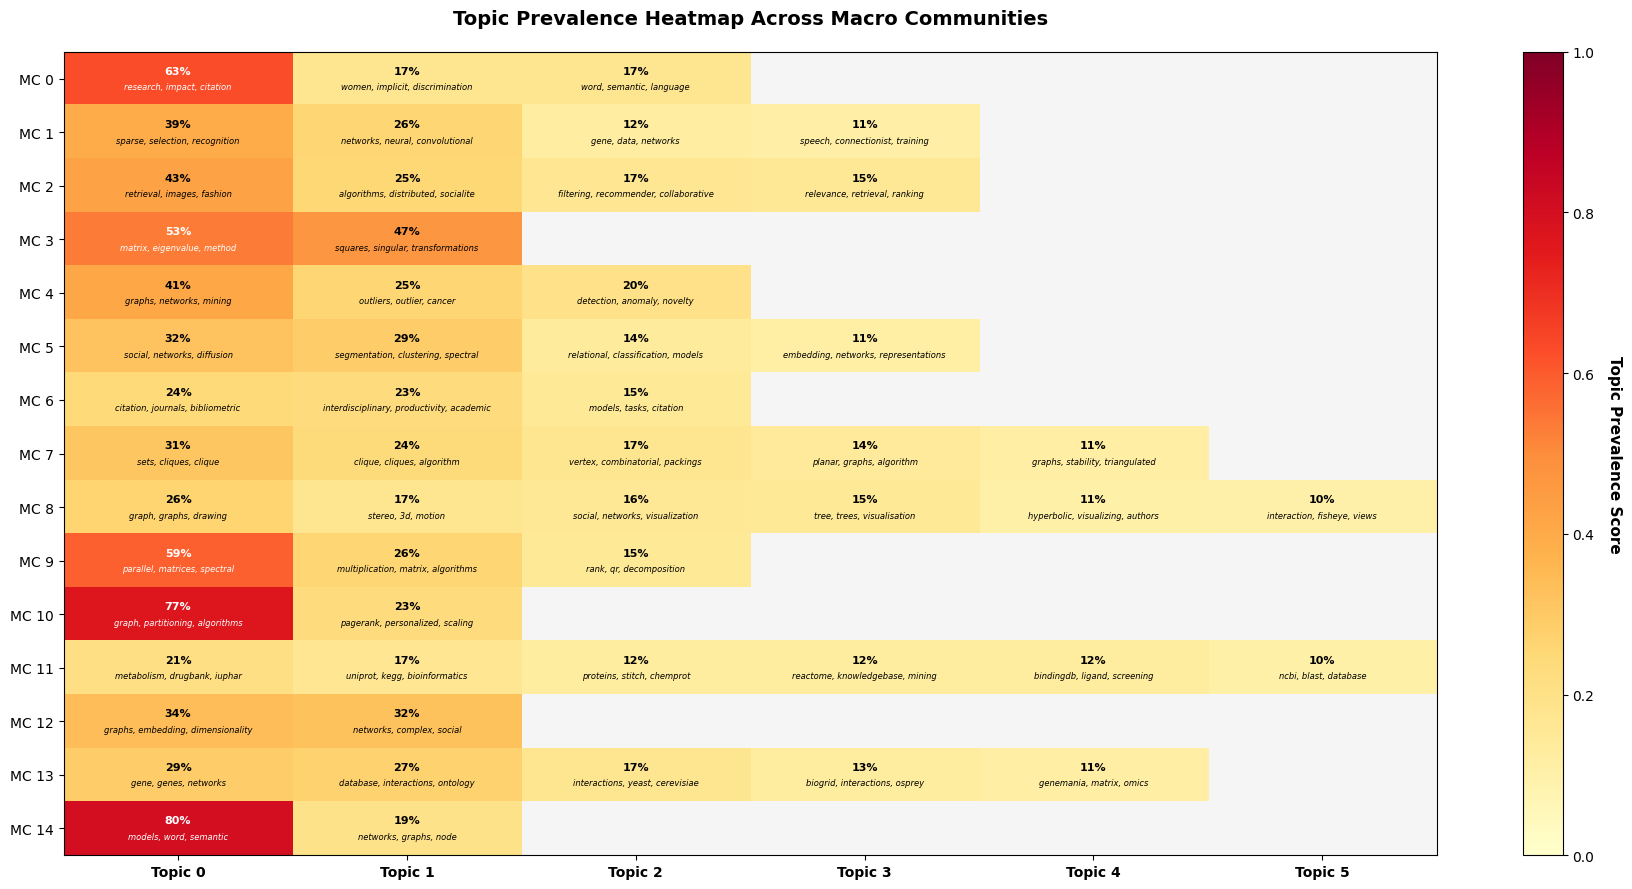

In [13]:
# 3. Heatmap: All Topics and Scores by Macro Community

all_macro_ids = sorted(macro_groups_df['Macro_Community'].unique())

# Find the maximum number of topics across all communities
max_topics = max(
    (data['num_topics'] for data in macro_community_topics.values()),
    default=0
)

# Build the heatmap matrix (communities x topics) and collect keyword labels
heatmap_data = np.full((len(all_macro_ids), max_topics), np.nan)
keyword_labels = [['' for _ in range(max_topics)] for _ in range(len(all_macro_ids))]

for idx, mid in enumerate(all_macro_ids):
    if mid in macro_community_topics:
        for td in macro_community_topics[mid]['topic_details']:
            col = td['topic_id']
            if col < max_topics:
                heatmap_data[idx, col] = td['score']
                keyword_labels[idx][col] = ', '.join(td['keywords'][:3])

# Plot
fig, ax = plt.subplots(figsize=(max(12, max_topics * 3), max(6, len(all_macro_ids) * 0.6)))

# Use a masked array so NaN cells stay white
masked_data = np.ma.masked_invalid(heatmap_data)
cmap = plt.cm.YlOrRd
cmap.set_bad(color='whitesmoke')

im = ax.imshow(masked_data, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# Axis labels
ax.set_xticks(np.arange(max_topics))
ax.set_xticklabels([f'Topic {i}' for i in range(max_topics)], fontsize=10, fontweight='bold')
ax.set_yticks(np.arange(len(all_macro_ids)))
ax.set_yticklabels([f'MC {mid}' for mid in all_macro_ids], fontsize=10)

# Annotate each cell with score and top keywords
for i in range(len(all_macro_ids)):
    for j in range(max_topics):
        if not np.isnan(heatmap_data[i, j]):
            score_text = f"{heatmap_data[i, j]:.0%}"
            kw_text = keyword_labels[i][j]
            color = 'white' if heatmap_data[i, j] > 0.5 else 'black'
            ax.text(j, i - 0.15, score_text, ha='center', va='center',
                    color=color, fontsize=8, fontweight='bold')
            ax.text(j, i + 0.15, kw_text, ha='center', va='center',
                    color=color, fontsize=6, style='italic')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Topic Prevalence Score', rotation=270, labelpad=20, fontsize=11, fontweight='bold')

ax.set_title('Topic Prevalence Heatmap Across Macro Communities', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [14]:
# 4. Summary Statistics Table

all_macro_ids_list = sorted(macro_groups_df['Macro_Community'].unique())

summary_data = []
for macro_id in all_macro_ids_list:
    if macro_id in macro_community_topics:
        data = macro_community_topics[macro_id]
        topic_details = data['topic_details']
        scores = [td['score'] for td in topic_details]

        # Dominant topic = the one with the highest score
        dominant = max(topic_details, key=lambda td: td['score'])
        dominant_keywords = ', '.join(dominant['keywords'][:5])

        summary_data.append({
            'Macro_Community': macro_id,
            'Num_Topics': data['num_topics'],
            'Num_Documents': data['num_documents'],
            'Coherence_cv': data.get('coherence', 0.0),
            'Dominant_Keywords': dominant_keywords,
            'Min_Score': np.min(scores),
            'Max_Score': np.max(scores),
            'Avg_Score': np.mean(scores),
        })
    else:
        row = macro_groups_df[macro_groups_df['Macro_Community'] == macro_id].iloc[0]
        num_docs = len(str(row['PaperTitles']).split('; ')) if pd.notna(row['PaperTitles']) else 0
        summary_data.append({
            'Macro_Community': macro_id,
            'Num_Topics': 0,
            'Num_Documents': num_docs,
            'Coherence_cv': np.nan,
            'Dominant_Keywords': 'N/A (failed)',
            'Min_Score': np.nan,
            'Max_Score': np.nan,
            'Avg_Score': np.nan,
        })

summary_df = pd.DataFrame(summary_data)

print("\n" + "=" * 130)
print("SUMMARY STATISTICS: Topic Analysis Across Macro Communities")
print("=" * 130 + "\n")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 60)

print(summary_df.to_string(index=False))
print("\n" + "=" * 130)

# Overall insights (only from successful communities)
successful = summary_df.dropna(subset=['Coherence_cv'])
total_topics = successful['Num_Topics'].sum()
total_docs = summary_df['Num_Documents'].sum()
avg_coherence = successful['Coherence_cv'].mean()

print(f"\nOVERALL INSIGHTS:")
print(f"  - Total Communities: {len(summary_df)} ({len(successful)} successful, {len(summary_df) - len(successful)} failed)")
print(f"  - Total Topics Discovered: {total_topics}")
print(f"  - Total Documents Analyzed: {total_docs}")
print(f"  - Average Topics per Community: {successful['Num_Topics'].mean():.1f}")
print(f"  - Average Coherence (c_v): {avg_coherence:.4f}")
print(f"  - Best Coherence: MC {successful.loc[successful['Coherence_cv'].idxmax(), 'Macro_Community']} ({successful['Coherence_cv'].max():.4f})")
print(f"  - Worst Coherence: MC {successful.loc[successful['Coherence_cv'].idxmin(), 'Macro_Community']} ({successful['Coherence_cv'].min():.4f})")
print(f"  - Community with Most Topics: MC {successful.loc[successful['Num_Topics'].idxmax(), 'Macro_Community']} ({successful['Num_Topics'].max()} topics)")
print(f"  - Community with Most Documents: MC {summary_df.loc[summary_df['Num_Documents'].idxmax(), 'Macro_Community']} ({summary_df['Num_Documents'].max()} docs)")
print("=" * 130)


SUMMARY STATISTICS: Topic Analysis Across Macro Communities

 Macro_Community  Num_Topics  Num_Documents  Coherence_cv                                                 Dominant_Keywords  Min_Score  Max_Score  Avg_Score
               0           3            639      0.364404                   research, impact, citation, sociology, academic   0.172144   0.625978   0.323944
               1           4            440      0.316397            sparse, selection, recognition, models, dimensionality   0.109091   0.390909   0.218750
               2           4            293      0.384213                retrieval, images, fashion, multimedia, similarity   0.153584   0.426621   0.250000
               3           2             15      0.318270                     matrix, eigenvalue, method, algorithm, values   0.466667   0.533333   0.500000
               4           3            365      0.397664                       graphs, networks, mining, local, algorithms   0.197260   0.410959   0.287